In [11]:
import yfinance as yf

TICKERS = ['AAPL', 'MSFT', 'JPM', 'GS', 'BAC', 'XOM', 'JNJ', 'AMZN', 'TSLA', 'NVDA']

raw = yf.download(TICKERS, start='2010-01-01', auto_adjust=True, progress=False)
df = raw['Close'].copy()

print("Number of rows is:", df.shape)
print(df.head())
df.info()



Number of rows is: (4140, 10)
Ticker          AAPL    AMZN        BAC          GS        JNJ        JPM  \
Date                                                                        
2010-01-04  6.406480  6.6950  12.038231  129.387360  39.974815  28.279200   
2010-01-05  6.417556  6.7345  12.429532  131.674850  39.511288  28.826969   
2010-01-06  6.315476  6.6125  12.575310  130.269485  39.832664  28.985369   
2010-01-07  6.303801  6.5000  12.989632  132.818634  39.548374  29.559525   
2010-01-08  6.345712  6.6760  12.874540  130.306870  39.684322  29.486925   

Ticker           MSFT      NVDA  TSLA        XOM  
Date                                              
2010-01-04  23.027515  0.423290   NaN  37.377258  
2010-01-05  23.034943  0.429471   NaN  37.523216  
2010-01-06  22.893583  0.432219   NaN  37.847530  
2010-01-07  22.655489  0.423748   NaN  37.728622  
2010-01-08  22.811745  0.424664   NaN  37.577271  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4140 entries, 2010-0

Missing values per column: Ticker
AAPL      1
AMZN      1
BAC       1
GS        1
JNJ       1
JPM       1
MSFT      1
NVDA      1
TSLA    123
XOM       1
dtype: int64
Top 3 columns with the highest missing values: Ticker
TSLA    123
AAPL      1
AMZN      1
dtype: int64
Top 3 columns with the lowest missing values: Ticker
AAPL    1
AMZN    1
BAC     1
dtype: int64


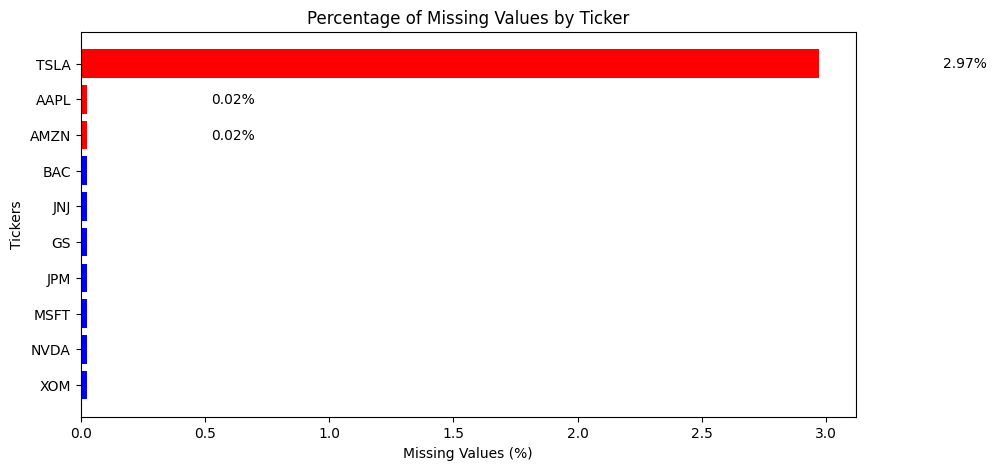


Rows after cleaning: 4018


In [12]:
import matplotlib.pyplot as plt

missing_values = df.isnull().sum()
print('Missing values per column:', missing_values)

highest_missing = missing_values.sort_values(ascending=False).head(3)
print('Top 3 columns with the highest missing values:', highest_missing)

lowest_missing = missing_values.sort_values(ascending=True).head(3)
print('Top 3 columns with the lowest missing values:', lowest_missing)

missing_percentage = (missing_values / len(df)) * 100
missing_percentage = missing_percentage.sort_values(ascending=False)

highlight_columns = highest_missing.index.tolist()
bar_colours = []

for column_name in missing_percentage.index:
    if column_name in highlight_columns:
        bar_colours.append('red')
    else:
        bar_colours.append('blue')

plt.figure(figsize=(10, 5))
plt.barh(missing_percentage.index, missing_percentage.values, color=bar_colours)
plt.gca().invert_yaxis()
plt.title("Percentage of Missing Values by Ticker")
plt.xlabel("Missing Values (%)")
plt.ylabel("Tickers")

position = 0
for column_name in missing_percentage.index:
    if column_name in highlight_columns:
        percentage_value = missing_percentage[column_name]
        plt.text(percentage_value + 0.5, position, str(round(percentage_value, 2)) + "%", va='center')
    position = position + 1

plt.show()

# Forward-fill any gaps from staggered listing dates, then drop remaining NaNs
df = df.ffill().dropna()
print(f"\nRows after cleaning: {len(df)}")

In [13]:
df = df.sort_index()
df.head()

Ticker,AAPL,AMZN,BAC,GS,JNJ,JPM,MSFT,NVDA,TSLA,XOM
Date,,,,,,,,,,
2010-06-29,7.668561,5.4305,11.192951,100.468224,37.229801,24.485405,17.502897,0.239918,1.592667,31.380348
2010-06-30,7.529659,5.4630,11.039311,98.597984,37.116684,24.188091,17.277632,0.233737,1.588667,31.259851
2010-07-01,7.438354,5.5480,10.770432,98.500320,37.122959,23.870523,17.390266,0.237629,1.464000,31.007874
2010-07-02,7.392254,5.4570,10.632151,98.455231,37.129246,23.705118,17.472857,0.234653,1.280000,30.985971
2010-07-06,7.442847,5.5030,10.801161,99.341537,37.129246,24.035925,17.885843,0.232134,1.074000,31.473480


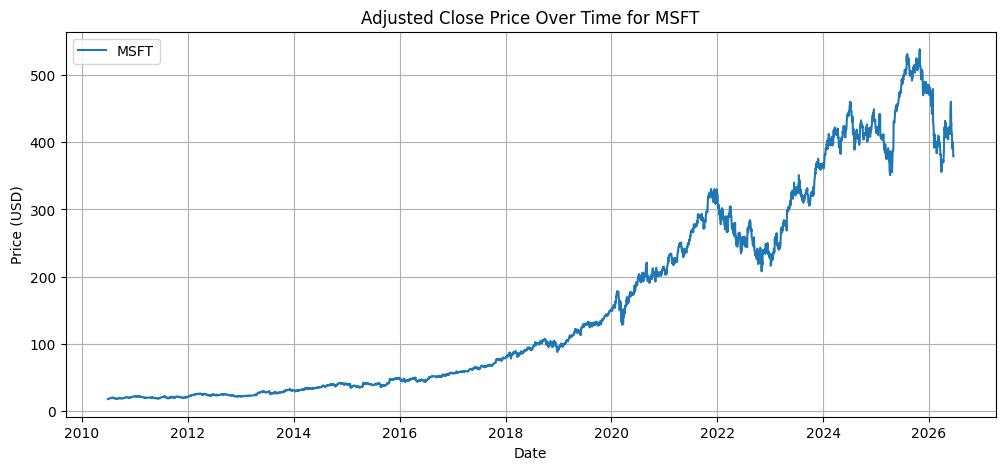

In [14]:
import matplotlib.pyplot as plt

ticker = 'MSFT'

plt.figure(figsize=(12, 5))
plt.plot(df.index, df[ticker], linestyle='-', label=ticker)
plt.title(f'Adjusted Close Price Over Time for {ticker}')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

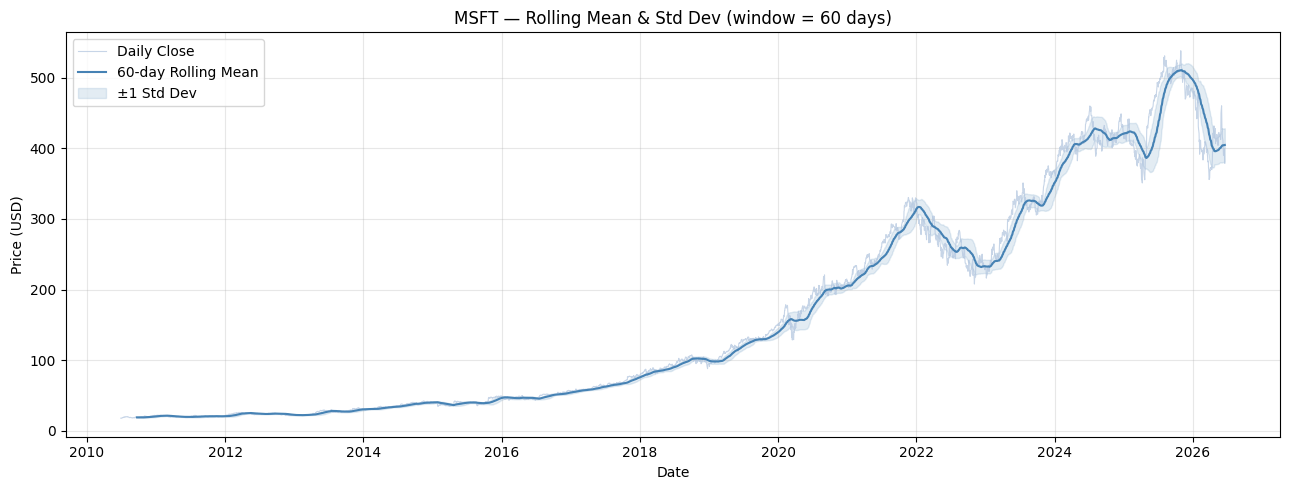

In [15]:
ticker = 'MSFT'
window_size = 60  # roughly 3 months of trading days

price_series = df[ticker]
rolling_mean = price_series.rolling(window=window_size).mean()
rolling_std  = price_series.rolling(window=window_size).std()

plt.figure(figsize=(13, 5))
plt.plot(price_series.index, price_series,
         label='Daily Close', color='lightsteelblue', linewidth=0.8, alpha=0.7)
plt.plot(rolling_mean.index, rolling_mean,
         label=f'{window_size}-day Rolling Mean', color='steelblue', linewidth=1.5)
plt.fill_between(rolling_mean.index,
                 rolling_mean - rolling_std,
                 rolling_mean + rolling_std,
                 color='steelblue', alpha=0.15, label='±1 Std Dev')

plt.title(f'{ticker} — Rolling Mean & Std Dev (window = {window_size} days)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

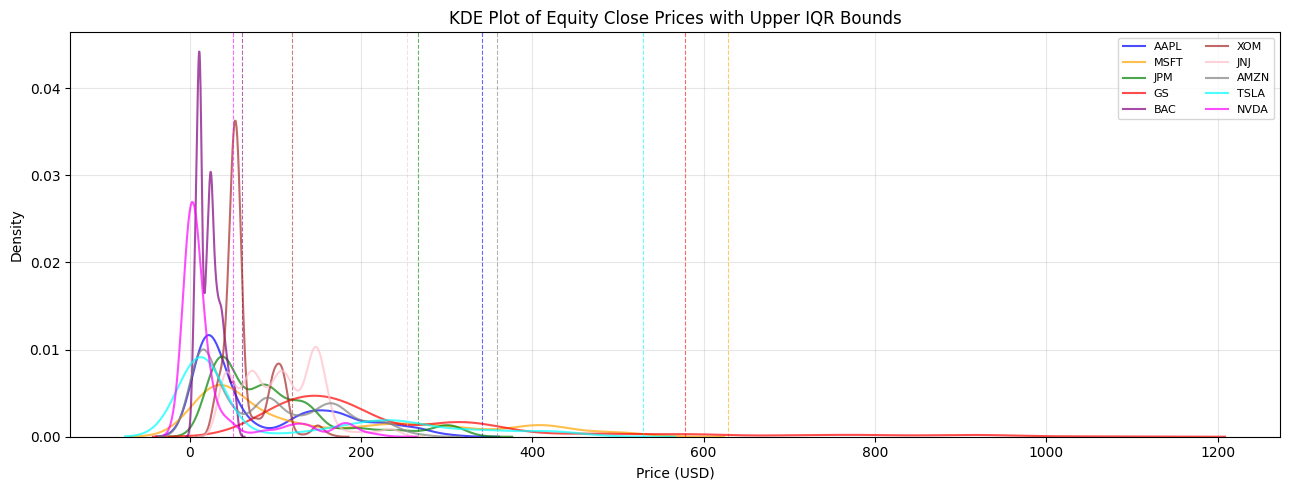

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

ticker_colours = {
    'AAPL': 'blue',
    'MSFT': 'orange',
    'JPM':  'green',
    'GS':   'red',
    'BAC':  'purple',
    'XOM':  'brown',
    'JNJ':  'pink',
    'AMZN': 'grey',
    'TSLA': 'cyan',
    'NVDA': 'magenta'
}

def calculate_iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

plt.figure(figsize=(13, 5))

for ticker, colour in ticker_colours.items():

    values = df[ticker].dropna()

    sns.kdeplot(values, label=ticker, color=colour, alpha=0.7)

    lower, upper = calculate_iqr_bounds(values)
    plt.axvline(upper, color=colour, linestyle='--', linewidth=0.8, alpha=0.6)

plt.title('KDE Plot of Equity Close Prices with Upper IQR Bounds')
plt.xlabel('Price (USD)')
plt.ylabel('Density')
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipykernel_2829/209760322.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(price_data, labels=TICKERS, patch_artist=True,


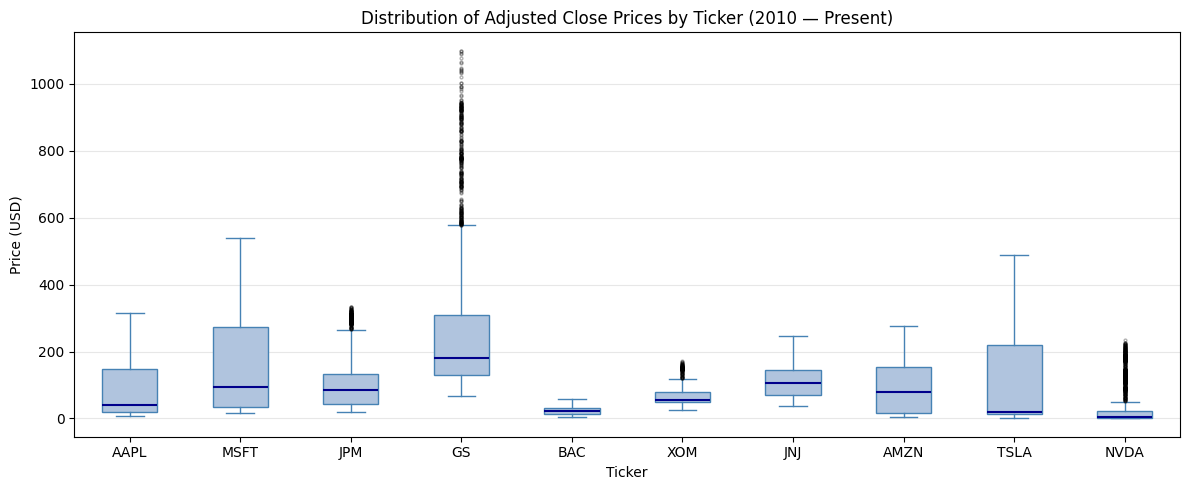

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

price_data = [df[ticker].dropna().values for ticker in TICKERS]

plt.boxplot(price_data, labels=TICKERS, patch_artist=True,
            boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
            medianprops=dict(color='darkblue', linewidth=1.5),
            whiskerprops=dict(color='steelblue'),
            capprops=dict(color='steelblue'),
            flierprops=dict(marker='o', color='steelblue', alpha=0.3, markersize=2))

plt.title('Distribution of Adjusted Close Prices by Ticker (2010 — Present)')
plt.xlabel('Ticker')
plt.ylabel('Price (USD)')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Mean closing prices over the last 252 trading days:
Ticker
GS      834.31
MSFT    460.76
TSLA    397.74
JPM     301.39
AAPL    256.83
AMZN    230.92
JNJ     202.99
NVDA    185.56
XOM     127.71
BAC      50.63
dtype: float64

Percentage price change over the last 252 trading days:
Ticker
GS      76.51
JNJ     59.26
AAPL    51.15
NVDA    40.86
XOM     28.30
BAC     28.19
JPM     24.09
TSLA    23.08
AMZN    11.75
MSFT   -20.47
dtype: float64

Best performer : GS (76.51%)
Worst performer: MSFT (-20.47%)


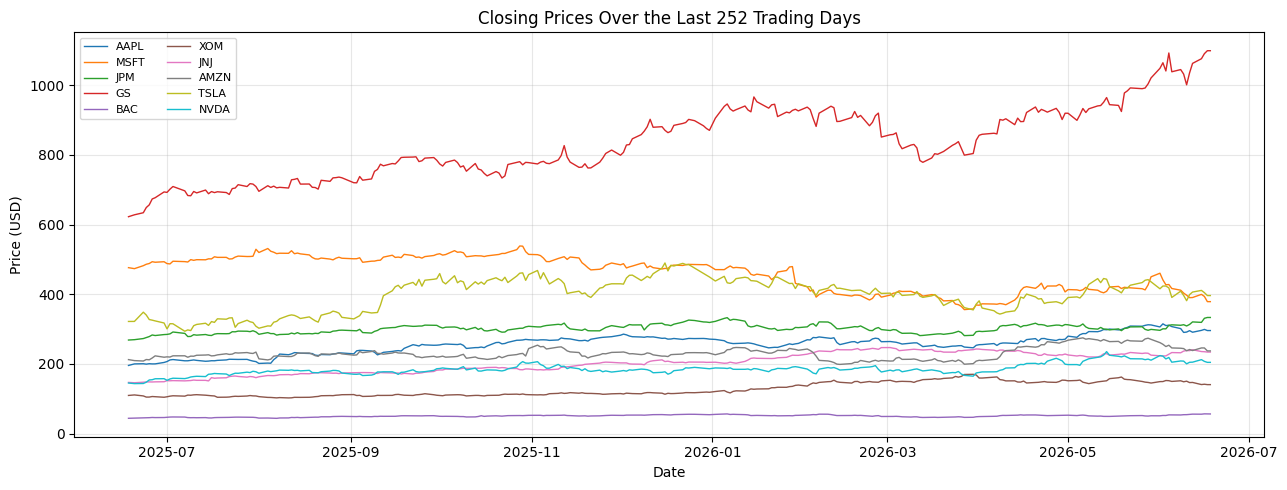

In [18]:
import matplotlib.pyplot as plt

n = 252  # approximately one trading year

recent_data = df.tail(n)

recent_mean = recent_data.mean().sort_values(ascending=False)
print(f'Mean closing prices over the last {n} trading days:')
print(recent_mean.round(2))

pct_change = ((recent_data.iloc[-1] - recent_data.iloc[0]) / recent_data.iloc[0] * 100).sort_values(ascending=False)
print(f'\nPercentage price change over the last {n} trading days:')
print(pct_change.round(2))

best_performer  = pct_change.idxmax()
worst_performer = pct_change.idxmin()
print(f'\nBest performer : {best_performer} ({round(pct_change[best_performer], 2)}%)')
print(f'Worst performer: {worst_performer} ({round(pct_change[worst_performer], 2)}%)')

plt.figure(figsize=(13, 5))
for ticker in TICKERS:
    plt.plot(recent_data.index, recent_data[ticker], label=ticker, linewidth=1)

plt.title(f'Closing Prices Over the Last {n} Trading Days')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [19]:
import pandas_datareader.data as web
import pandas as pd

cpi_raw = web.DataReader('CPIAUCSL', 'fred', start='2010-01-01')
cpi_raw.index = pd.to_datetime(cpi_raw.index)
cpi_raw.columns = ['CPI']

df_monthly = df.resample('ME').last()

df_monthly.index = df_monthly.index.to_period('M').to_timestamp()
cpi_raw.index    = cpi_raw.index.to_period('M').to_timestamp()

df_with_cpi = df_monthly.merge(cpi_raw, left_index=True, right_index=True, how='inner')

for ticker in TICKERS:
    df_with_cpi[ticker + '_Adj'] = df_with_cpi[ticker] * (100 / df_with_cpi['CPI'])

print('Rows after CPI merge:', len(df_with_cpi))
print(df_with_cpi[[TICKERS[0], TICKERS[0] + '_Adj', 'CPI']].head())


Rows after CPI merge: 192
                AAPL  AAPL_Adj      CPI
2010-06-01  7.529659  3.466710  217.199
2010-07-01  7.700886  3.538929  217.605
2010-08-01  7.277302  3.339391  217.923
2010-09-01  8.494180  3.891504  218.275
2010-10-01  9.009964  4.113481  219.035


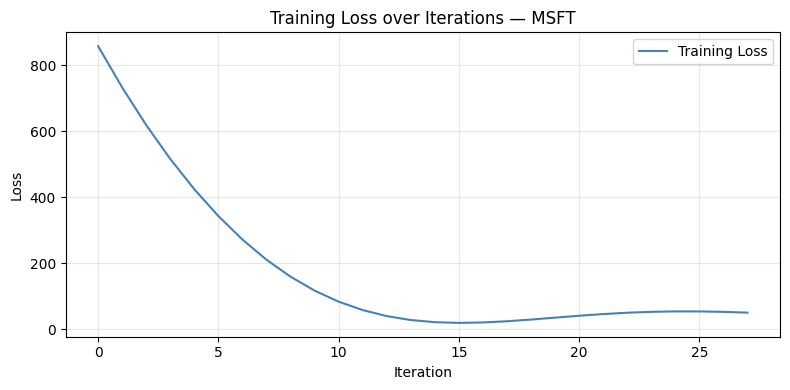

Ticker           : MSFT
Forecast horizon : 24 months
MAE              : $10.07
RMSE             : $12.22


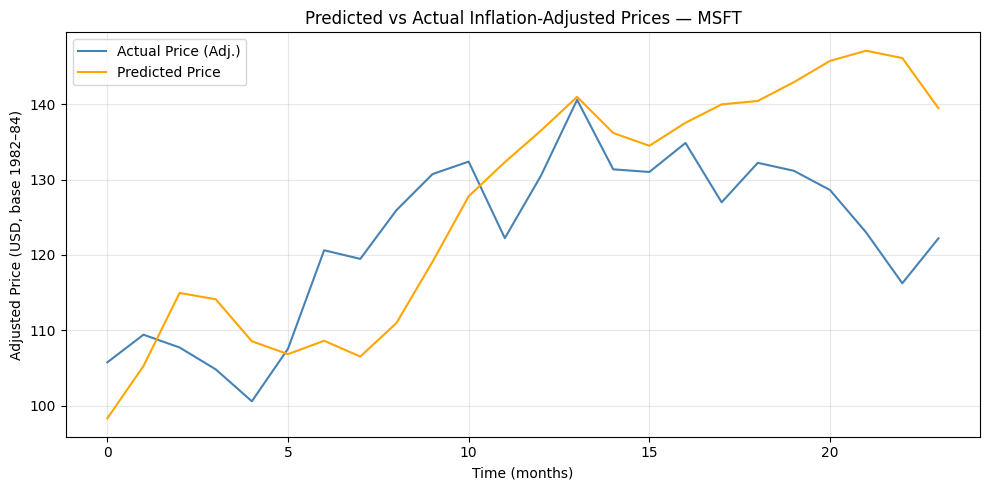

In [20]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

ticker          = 'MSFT'
window_size     = 12   # number of past months used as input features
forecast_horizon = 24  # number of months ahead to evaluate

price_series = df_with_cpi[ticker + '_Adj'].dropna().values

X = []
y = []

for i in range(len(price_series) - window_size):
    X.append(price_series[i:i + window_size])
    y.append(price_series[i + window_size])

X = np.array(X)
y = np.array(y)

split = int(len(X) * 0.8)

X_train = X[:split]
X_test  = X[split:]
y_train = y[:split]
y_test  = y[split:]

model = MLPRegressor(
    hidden_layer_sizes=(50,),
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

model.fit(X_train, y_train)

plt.figure(figsize=(8, 4))
plt.plot(model.loss_curve_, label='Training Loss', color='steelblue')
plt.title(f'Training Loss over Iterations — {ticker}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

y_pred = model.predict(X_test)

y_test_horizon = y_test[:forecast_horizon]
y_pred_horizon = y_pred[:forecast_horizon]

mae  = mean_absolute_error(y_test_horizon, y_pred_horizon)
rmse = np.sqrt(mean_squared_error(y_test_horizon, y_pred_horizon))

print(f'Ticker           : {ticker}')
print(f'Forecast horizon : {forecast_horizon} months')
print(f'MAE              : ${mae:,.2f}')
print(f'RMSE             : ${rmse:,.2f}')

# Plot predicted vs actual
plt.figure(figsize=(10, 5))
plt.plot(y_test_horizon, label='Actual Price (Adj.)', color='steelblue')
plt.plot(y_pred_horizon, label='Predicted Price',     color='orange')
plt.title(f'Predicted vs Actual Inflation-Adjusted Prices — {ticker}')
plt.xlabel('Time (months)')
plt.ylabel('Adjusted Price (USD, base 1982–84)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Sensitivity analysis for MSFT
  Window   Horizon         MAE        RMSE
--------------------------------------------
       6        24        7.93        9.28
       6        36       10.44       12.97
       6        48       10.25       12.80
      12        24       10.07       12.22
      12        36       12.32       15.45
      12        48       12.32       15.45
      24        24       12.33       15.08
      24        36       14.88       18.71
      24        48       14.88       18.71


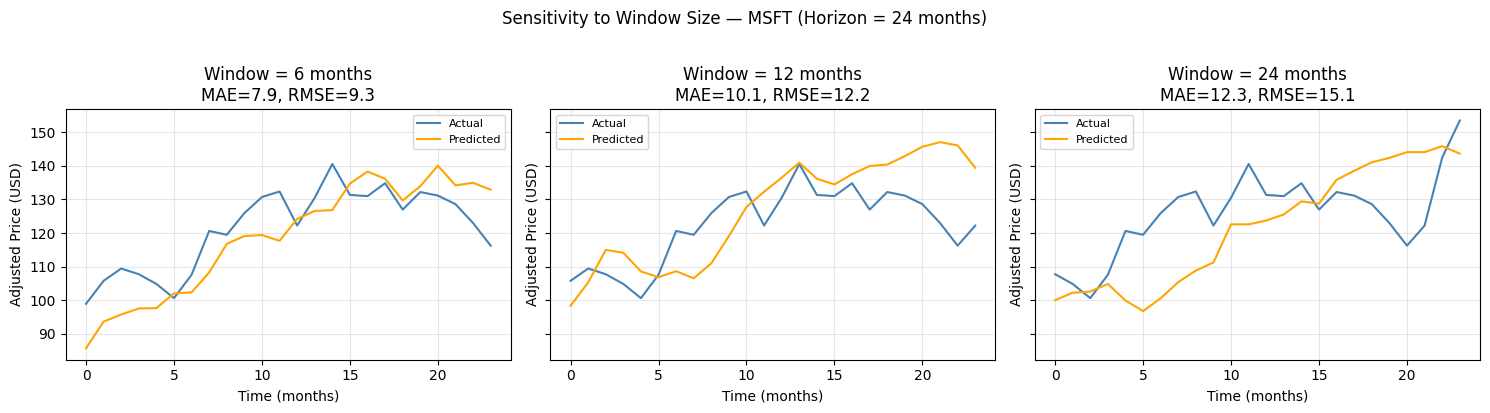

In [21]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

def train_and_evaluate_mlp(price_series, window_size, forecast_horizon):
    X = []
    y = []

    for i in range(len(price_series) - window_size):
        X.append(price_series[i:i + window_size])
        y.append(price_series[i + window_size])

    X = np.array(X)
    y = np.array(y)

    split = int(len(X) * 0.8)

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    mlp = MLPRegressor(
        hidden_layer_sizes=(50,),
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
    )
    mlp.fit(X_train, y_train)

    y_pred = mlp.predict(X_test)

    y_test_horizon = y_test[:forecast_horizon]
    y_pred_horizon = y_pred[:forecast_horizon]

    mae  = mean_absolute_error(y_test_horizon, y_pred_horizon)
    rmse = np.sqrt(mean_squared_error(y_test_horizon, y_pred_horizon))

    return mae, rmse, y_test_horizon, y_pred_horizon

# Sensitivity grid
ticker       = 'MSFT'
price_series = df_with_cpi[ticker + '_Adj'].dropna().values

window_sizes      = [6, 12, 24]
forecast_horizons = [24, 36, 48]

print(f'Sensitivity analysis for {ticker}')
print(f'{"Window":>8}  {"Horizon":>8}  {"MAE":>10}  {"RMSE":>10}')
print('-' * 44)

for window_size in window_sizes:
    for forecast_horizon in forecast_horizons:
        mae, rmse, _, _ = train_and_evaluate_mlp(price_series, window_size, forecast_horizon)
        print(f'{window_size:>8}  {forecast_horizon:>8}  {mae:>10.2f}  {rmse:>10.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, window_size in zip(axes, window_sizes):
    mae, rmse, y_test_h, y_pred_h = train_and_evaluate_mlp(price_series, window_size, 24)
    ax.plot(y_test_h, label='Actual',    color='steelblue')
    ax.plot(y_pred_h, label='Predicted', color='orange')
    ax.set_title(f'Window = {window_size} months\nMAE={mae:.1f}, RMSE={rmse:.1f}')
    ax.set_xlabel('Time (months)')
    ax.set_ylabel('Adjusted Price (USD)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Sensitivity to Window Size — {ticker} (Horizon = 24 months)', y=1.02)
plt.tight_layout()
plt.show()


RMSE by ticker (window = 12, horizon = 24 months):
   BAC  MAE=    1.03  RMSE=    1.28
   XOM  MAE=    1.75  RMSE=    2.28
   JNJ  MAE=    3.38  RMSE=    4.27
  AMZN  MAE=    5.06  RMSE=    6.49
  NVDA  MAE=    6.12  RMSE=    6.87
   JPM  MAE=    6.02  RMSE=    7.03
  AAPL  MAE=    6.44  RMSE=    7.67
  MSFT  MAE=   10.07  RMSE=   12.22
    GS  MAE=   13.87  RMSE=   17.52
  TSLA  MAE=   15.57  RMSE=   18.50


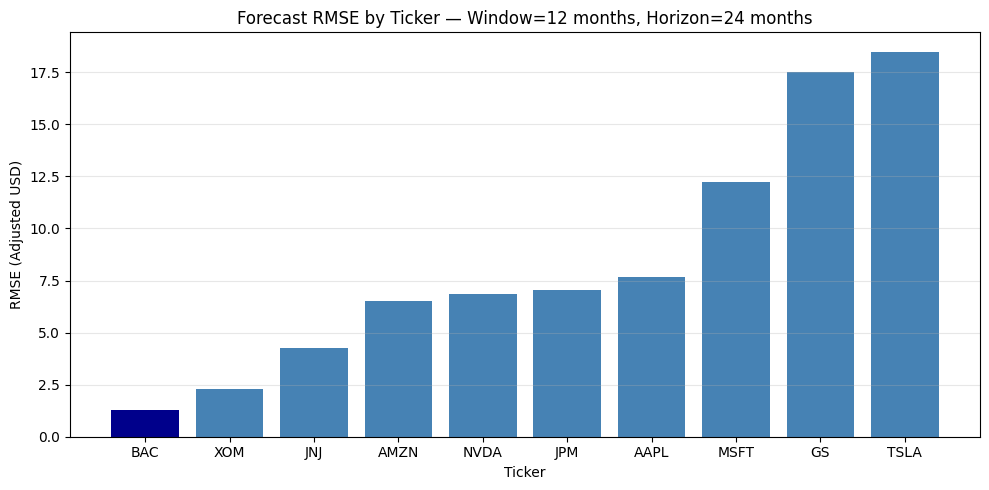

In [22]:
import matplotlib.pyplot as plt
import numpy as np

window_size      = 12
forecast_horizon = 24

rmse_by_ticker = {}
mae_by_ticker  = {}

for ticker in TICKERS:
    price_series = df_with_cpi[ticker + '_Adj'].dropna().values
    mae, rmse, _, _ = train_and_evaluate_mlp(price_series, window_size, forecast_horizon)
    rmse_by_ticker[ticker] = rmse
    mae_by_ticker[ticker]  = mae

sorted_tickers = sorted(rmse_by_ticker, key=rmse_by_ticker.get)
sorted_rmse    = [rmse_by_ticker[t] for t in sorted_tickers]

print(f'RMSE by ticker (window = {window_size}, horizon = {forecast_horizon} months):')
for ticker in sorted_tickers:
    print(f'  {ticker:>4}  MAE={mae_by_ticker[ticker]:>8.2f}  RMSE={rmse_by_ticker[ticker]:>8.2f}')

plt.figure(figsize=(10, 5))
bar_colours = ['steelblue' if t != sorted_tickers[0] else 'darkblue' for t in sorted_tickers]
plt.bar(sorted_tickers, sorted_rmse, color=bar_colours)
plt.title(f'Forecast RMSE by Ticker — Window={window_size} months, Horizon={forecast_horizon} months')
plt.xlabel('Ticker')
plt.ylabel('RMSE (Adjusted USD)')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
